# 🛒 Proyecto 4 — Segmentación de Clientes con Clustering RFM

Este proyecto aplica técnicas de **aprendizaje no supervisado** para segmentar clientes
de un comercio minorista online utilizando el modelo **RFM** (Recency, Frequency, Monetary).

A partir de los datos de transacciones del dataset *Online Retail* (UCI),
se construyen perfiles de clientes y se identifican **4 segmentos accionables**:
VIP, Nuevos, En riesgo e Hibernando.

# **1- Librerías**

In [52]:
# --- 1. Core ---
import numpy as np
import pandas as pd
from datetime import datetime


# --- 2. Visualización ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Estilo global (opcional, elegir uno)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="muted")


# --- 3. Preprocesamiento ---
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA


# --- 4. Modelos de clustering ---
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture


# --- 5. Métricas de evaluación ---
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)


# --- 6. Optimización de hiperparámetros (parameter sweep) ---
from itertools import product                    # DBSCAN: grid manual eps × min_samples
# from sklearn.model_selection import ParameterGrid  # alternativa más expresiva


# --- 7. Utilidades ---
import warnings
warnings.filterwarnings("ignore")

# Reproducibilidad
RANDOM_STATE = 42

# Formato de salida (opcional)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", 30)

# **2- Carga y Limpieza de datos**

- Cargar datos
- Datos nulos
- Datos duplicados



In [53]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url)

df2 = df.copy() # backup porque tarda en leer


In [54]:
# Filas y columnas
print(f'Cantidad de filas: {df.shape[0]}')
print(f'Cantidad de columnas: {df.shape[1]}')

Cantidad de filas: 541909
Cantidad de columnas: 8


In [55]:
# Filas duplicadas
print(f'Cantidad de filas duplicadas: {df.duplicated().sum()}')

Cantidad de filas duplicadas: 5268


In [56]:
df = df.drop_duplicates()
print(f'Cantidad de filas duplicadas: {df.duplicated().sum()}')

Cantidad de filas duplicadas: 0


In [57]:
# Datos nulos
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


## La columna Desceription no aporta valor así que procederé a eliminarla

## También voy a eliminar los registros en los que no CustomerID tenga valor NaN ya que no me sirve para la segmentación de clientes.

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    536641 non-null  object        
 1   StockCode    536641 non-null  object        
 2   Description  535187 non-null  object        
 3   Quantity     536641 non-null  int64         
 4   InvoiceDate  536641 non-null  datetime64[ns]
 5   UnitPrice    536641 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      536641 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.8+ MB


In [59]:
# Quito la columna Descripción por no aportar valor
df.drop(columns={'Description'},inplace=True)

In [60]:
# Elimino lineas conde CustromerID sea NaN
df = df.dropna(subset=["CustomerID"])

In [61]:
df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


In [62]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [63]:
df.groupby('Country').count().sort_values('TotalPrice', ascending=False).head(10)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
Country,,,,,,,
United Kingdom,356728,356728,356728,356728,356728,356728,356728
Germany,9480,9480,9480,9480,9480,9480,9480
France,8475,8475,8475,8475,8475,8475,8475
EIRE,7475,7475,7475,7475,7475,7475,7475
Spain,2528,2528,2528,2528,2528,2528,2528
Netherlands,2371,2371,2371,2371,2371,2371,2371
Belgium,2069,2069,2069,2069,2069,2069,2069
Switzerland,1877,1877,1877,1877,1877,1877,1877
Portugal,1471,1471,1471,1471,1471,1471,1471


In [64]:
df.head(1)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,15.30


In [65]:
units = df.pop('UnitPrice')
price = df.pop('TotalPrice')


In [66]:
df.insert(3, 'UnitPrice', units)
df.insert(4, 'TotalPrice', price)


In [67]:
df.head(1)

,InvoiceNo,StockCode,Quantity,UnitPrice,TotalPrice,InvoiceDate,CustomerID,Country
0,536365,85123A,6,2.55,15.30,2010-12-01 08:26:00,17850.00,United Kingdom


# **3- EDA**

- Distribuciones
- Outliers
- Correlaciones

In [68]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'TotalPrice',
       'InvoiceDate', 'CustomerID', 'Country'],
      dtype='object')

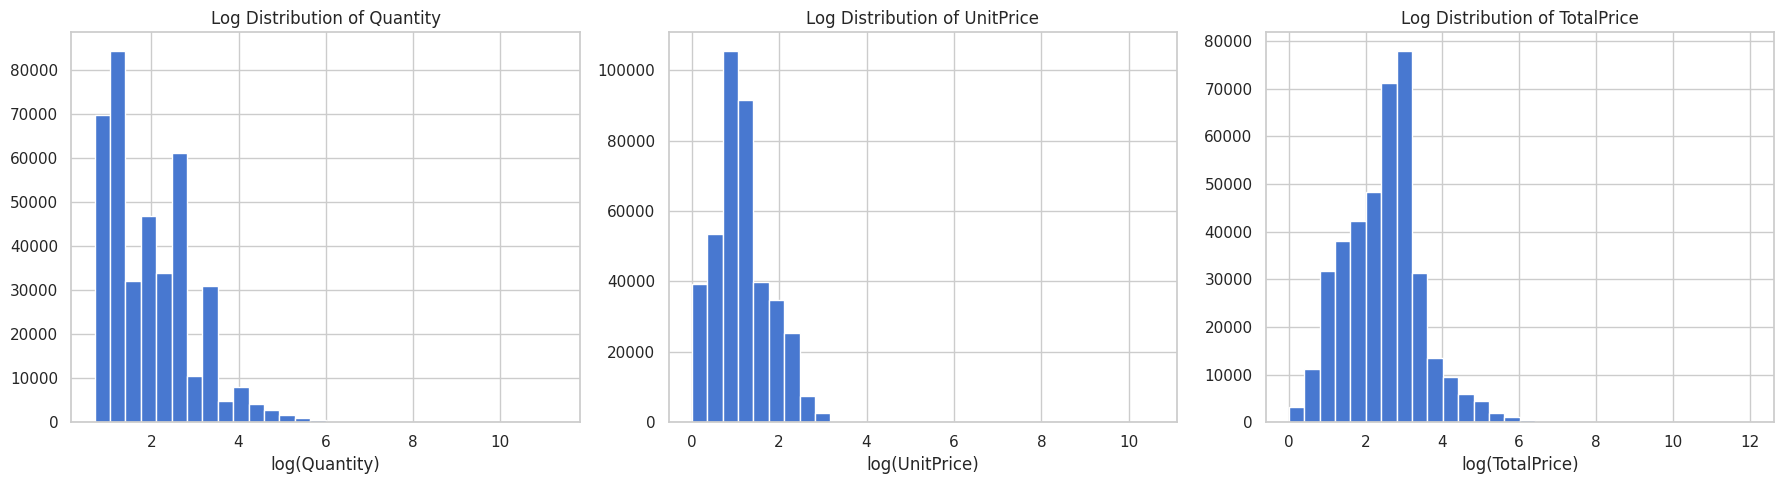

In [69]:
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, col in zip(axes, num_cols):

    data = df[df[col] > 0][col]

    ax.hist(np.log1p(data), bins=30) # Para que los outliers no deformen la gráfica
    ax.set_title(f'Log Distribution of {col}')
    ax.set_xlabel(f'log({col})')

plt.tight_layout()
plt.show()

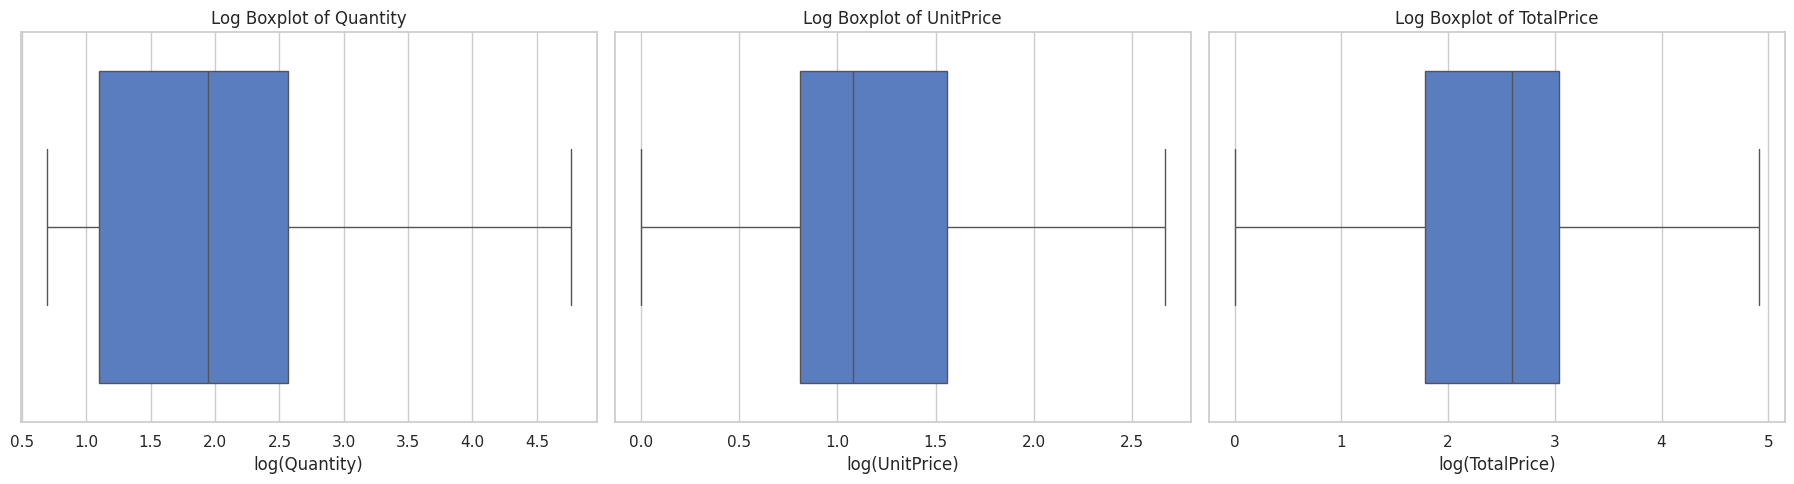

In [70]:
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, col in zip(axes, num_cols):

    data = df[df[col] > 0][col]

    sns.boxplot(
        x=np.log1p(data),
        ax=ax,
        showfliers=False
    )

    ax.set_title(f'Log Boxplot of {col}')
    ax.set_xlabel(f'log({col})')

plt.tight_layout()
plt.show()

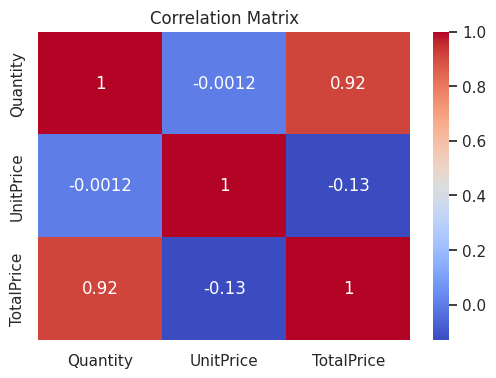

In [71]:
corr = df[num_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# **4- Feature engineering**

- Recency
- Frecuency
- Monetary

In [72]:
# Fecha de referencia para calcular cuanto hace que un cliente no compra. Es la fecha máxima
reference_date = df['InvoiceDate'].max()
reference_date

Timestamp('2011-12-09 12:50:00')

In [73]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
})

In [74]:
rfm.head()

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.00,325,2,0.00
12347.00,1,7,4310.00
12348.00,74,4,1797.24
12349.00,18,1,1757.55
12350.00,309,1,334.40


In [75]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [76]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.00,325,2,0.00
12347.00,1,7,4310.00
12348.00,74,4,1797.24
12349.00,18,1,1757.55
12350.00,309,1,334.40


In [77]:
rfm.sort_values(by="Monetary",ascending=False)

,Recency,Frequency,Monetary
CustomerID,,,
14646.00,1,77,279489.02
18102.00,0,62,256438.49
17450.00,7,55,187322.17
14911.00,0,248,132458.73
12415.00,23,26,123725.45
...,...,...,...
12503.00,337,1,-1126.00
17603.00,49,5,-1165.30
14213.00,371,1,-1192.20


In [78]:
# Me deshago de los valores negativos
rfm = rfm[rfm['Monetary'] > 0]
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12347.00,1,7,4310.00
12348.00,74,4,1797.24
12349.00,18,1,1757.55
12350.00,309,1,334.40
12352.00,35,11,1545.41
...,...,...,...
18280.00,277,1,180.60
18281.00,180,1,80.82
18282.00,7,3,176.60


# **5- Preprocesamiento**

- Log-transform (monetary/Frecuency)
- RobustScaler (outliers en rfm)
- PCA (opcional para visualizar)

In [79]:
# Log-transform

rfm_log = rfm.copy()
# rfm_log['Recency'] # NO SE TRANSFORMA!
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm['Monetary'])

In [80]:
# RobustScaler

features = ["Recency", "Frequency", "Monetary"]

scaler     = RobustScaler()
rfm_scaled = scaler.fit_transform(rfm_log[features])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=features, index=rfm.index)

In [81]:
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.00,-0.39,0.55,1.12
12348.00,0.21,0.18,0.60
12349.00,-0.25,-0.55,0.59
12350.00,2.15,-0.55,-0.40
12352.00,-0.11,0.88,0.51


In [82]:
# --- 3. PCA 2D (solo para visualización) ----------------------
#
#  Se aplica DESPUÉS del scaling, sobre los datos ya normalizados.
#  No reemplaza las features para el modelo: el clustering
#  corre sobre `rfm_scaled` (3 dimensiones reales).
#  PCA solo se usa para poder graficar en 2D.

pca        = PCA(n_components=2, random_state=RANDOM_STATE)
rfm_pca    = pca.fit_transform(rfm_scaled)
rfm_pca_df = pd.DataFrame(rfm_pca, columns=["PC1", "PC2"], index=rfm.index)

print(f"Varianza explicada por PC1 y PC2: "
      f"{pca.explained_variance_ratio_.sum():.1%}")
# Si este número es bajo (< 70%), el scatter 2D pierde información.
# En RFM de 3 features casi siempre supera el 85%, así que está bien.

Varianza explicada por PC1 y PC2: 94.7%


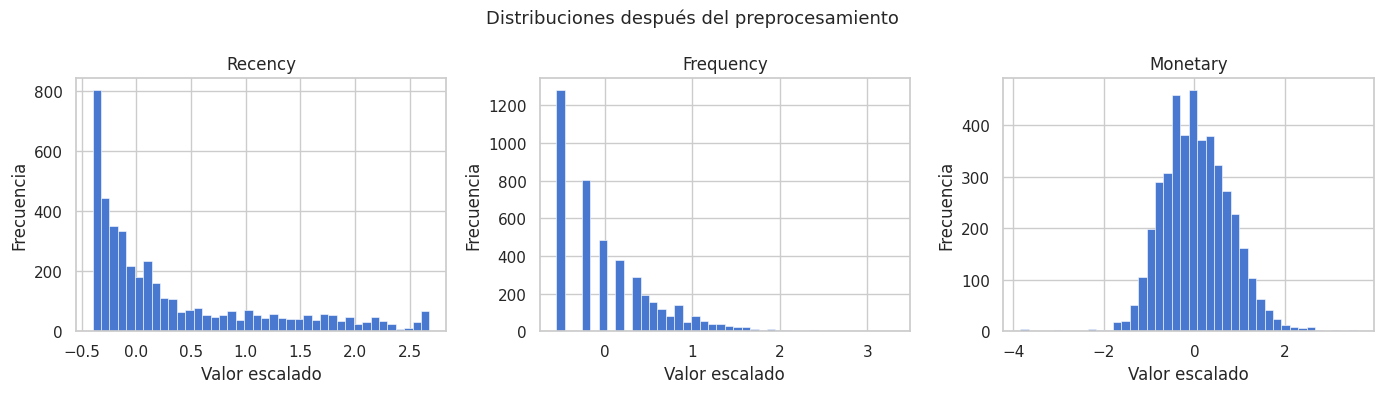

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Distribuciones después del preprocesamiento", fontsize=13)

for ax, col in zip(axes, features):
    ax.hist(rfm_scaled[col], bins=40, edgecolor="white", linewidth=0.4)
    ax.set_title(col)
    ax.set_xlabel("Valor escalado")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()



## **Recency** — Sesgo a la izquierda (valores negativos concentrados). La mayoría de clientes compró recientemente. Hay una cola larga hacia la derecha con clientes que llevan mucho tiempo sin comprar.
## **Frequency** — Fuerte sesgo positivo. La gran mayoría de clientes compra pocas veces (pico enorme cerca de -0.5/0). Solo unos pocos clientes son compradores muy frecuentes (cola larga hacia la derecha).
## **Monetary** — La más simétrica de las tres, con distribución casi normal centrada en 0. Hay algunos outliers en ambos extremos, especialmente valores muy negativos (-4) que podrían ser devoluciones o errores.

In [84]:
# Problemas: recency va a necesitar log y frecuency tiene una columna gigante en -0.5.

rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])

p99 = rfm["Frequency"].quantile(0.99)
rfm_log["Frequency"] = np.log1p(rfm["Frequency"].clip(upper=p99))

rfm_log['Monetary'] = np.log1p(rfm['Monetary'])



In [85]:
# Otra vez el scaler

scaler     = RobustScaler()
rfm_scaled = scaler.fit_transform(rfm_log[features])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=features, index=rfm.index)

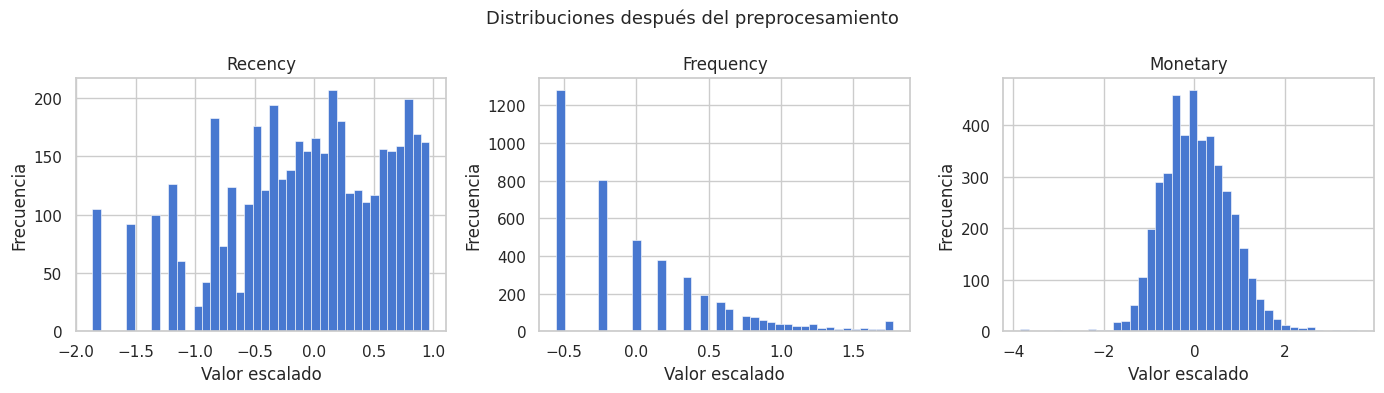

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Distribuciones después del preprocesamiento", fontsize=13)

for ax, col in zip(axes, features):
    ax.hist(rfm_scaled[col], bins=40, edgecolor="white", linewidth=0.4)
    ax.set_title(col)
    ax.set_xlabel("Valor escalado")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


## **Recency** — Gran mejora ✅

Antes: sesgo fuerte a la izquierda, pico enorme cerca de -0.5
Ahora: distribución mucho más uniforme y plana, valores entre -2 y 1.

## **Frequency** — Mejora parcial ⚠️

Antes y ahora: sigue con el pico dominante en -0.5 y cola larga
La asimetría persiste aunque la cola se acortó (antes llegaba a 3, ahora a ~1.8)
El log ayudó pero Frequency es estructuralmente difícil de normalizar en retail, porque el comportamiento 80/20 es muy pronunciado. Es esperable que quede así.

In [87]:
# Resumen
print("\n── rfm_scaled (input para el modelo) ──")
rfm_scaled.describe().round(2)


── rfm_scaled (input para el modelo) ──


,Recency,Frequency,Monetary
count,4322.00,4322.00,4322.00
mean,-0.09,0.05,0.05
std,0.70,0.57,0.75
min,-1.86,-0.55,-3.85
25%,-0.51,-0.55,-0.46
50%,0.00,0.00,-0.00
75%,0.49,0.45,0.54
max,0.97,1.78,3.60


In [88]:
print("\n── rfm_pca_df (solo para graficar) ──")
rfm_pca_df.head()


── rfm_pca_df (solo para graficar) ──


,PC1,PC2
CustomerID,,
12347.00,-1.36,0.17
12348.00,-0.48,0.24
12349.00,-0.42,-0.37
12350.00,1.70,0.98
12352.00,-0.96,0.17


# **6- Modelado**

- KMeans, DBScan, GMM (Gaussian Mixture Models), Aglomerative Clustering
- KMeans: barrer k con elbow + silhouette
- DBScan: barrer eps/min_samples

KMeans (k=4)
  Silhouette: 0.334 | Davies-Bouldin: 1.001 | Calinski-Harabasz: 3207.6


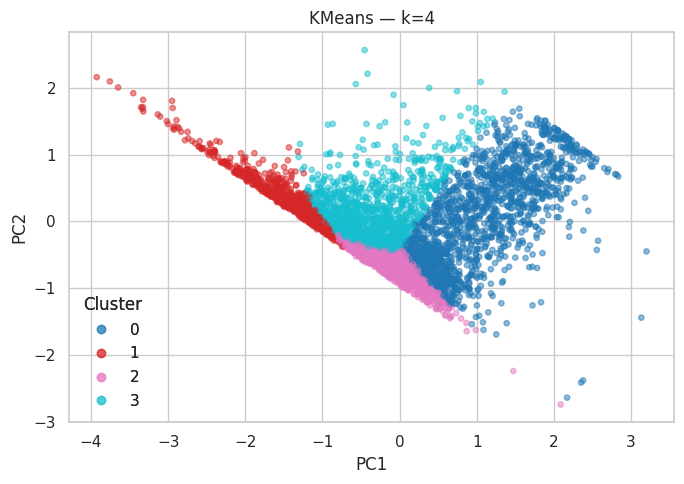


GMM (k=4)
  Silhouette: 0.143 | Davies-Bouldin: 2.024 | Calinski-Harabasz: 1821.8


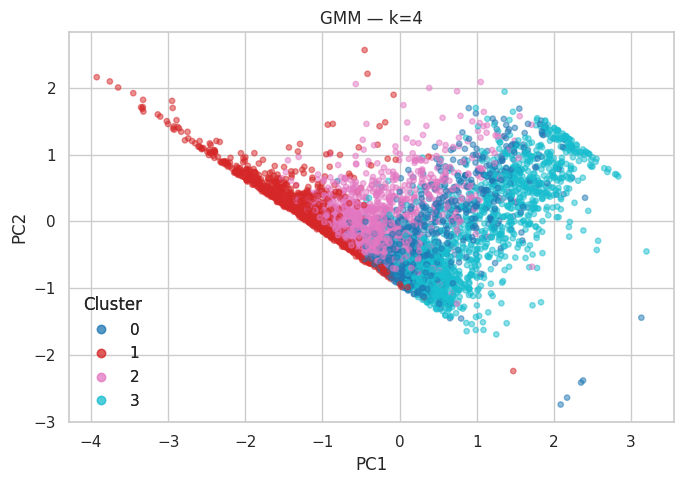


Agglomerative (k=4, linkage=ward)
  Silhouette: 0.270 | Davies-Bouldin: 1.114 | Calinski-Harabasz: 2636.7


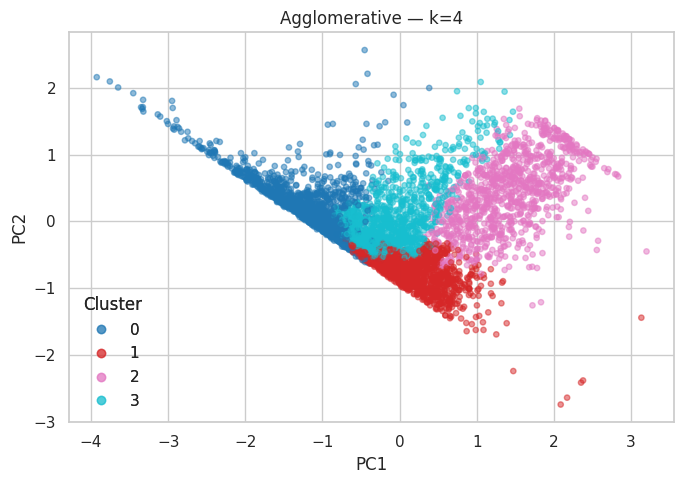

In [89]:
# ============================================================
#  MODELADO FINAL — k=4 fijo
#  KMeans · GMM · Agglomerative
#  Input: rfm_scaled · rfm_pca_df · rfm (original con índice)
# ============================================================

N_CLUSTERS = 4
model_results = []


# ── HELPER: scatter PCA ───────────────────────────────────────
#
#  Función reutilizable para graficar clusters en 2D.
#  Se llama después de entrenar cada modelo.

def plot_clusters_pca(pca_df, labels, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(
        pca_df["PC1"], pca_df["PC2"],
        c=labels, cmap="tab10", alpha=0.5, s=15
    )
    legend = ax.legend(*scatter.legend_elements(), title="Cluster")
    ax.add_artist(legend)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.tight_layout()
    plt.show()


# ── 1. KMEANS ─────────────────────────────────────────────────

km         = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
km_labels  = km.fit_predict(rfm_scaled)

km_sil = silhouette_score(rfm_scaled, km_labels)
km_db  = davies_bouldin_score(rfm_scaled, km_labels)
km_ch  = calinski_harabasz_score(rfm_scaled, km_labels)

print(f"KMeans (k={N_CLUSTERS})")
print(f"  Silhouette: {km_sil:.3f} | Davies-Bouldin: {km_db:.3f} | Calinski-Harabasz: {km_ch:.1f}")

plot_clusters_pca(rfm_pca_df, km_labels, f"KMeans — k={N_CLUSTERS}")

model_results.append({
    "modelo":            "KMeans",
    "parametros":        f"k={N_CLUSTERS}",
    "n_clusters":        N_CLUSTERS,
    "silhouette":        round(km_sil, 3),
    "davies_bouldin":    round(km_db, 3),
    "calinski_harabasz": round(km_ch, 1),
    "labels":            km_labels
})


# ── 2. GMM ────────────────────────────────────────────────────

gmm        = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE, n_init=5)
gmm.fit(rfm_scaled)
gmm_labels = gmm.predict(rfm_scaled)

gmm_sil = silhouette_score(rfm_scaled, gmm_labels)
gmm_db  = davies_bouldin_score(rfm_scaled, gmm_labels)
gmm_ch  = calinski_harabasz_score(rfm_scaled, gmm_labels)

print(f"\nGMM (k={N_CLUSTERS})")
print(f"  Silhouette: {gmm_sil:.3f} | Davies-Bouldin: {gmm_db:.3f} | Calinski-Harabasz: {gmm_ch:.1f}")

plot_clusters_pca(rfm_pca_df, gmm_labels, f"GMM — k={N_CLUSTERS}")

model_results.append({
    "modelo":            "GMM",
    "parametros":        f"k={N_CLUSTERS}",
    "n_clusters":        N_CLUSTERS,
    "silhouette":        round(gmm_sil, 3),
    "davies_bouldin":    round(gmm_db, 3),
    "calinski_harabasz": round(gmm_ch, 1),
    "labels":            gmm_labels
})


# ── 3. AGGLOMERATIVE ─────────────────────────────────────────

agg        = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage="ward")
agg_labels = agg.fit_predict(rfm_scaled)

agg_sil = silhouette_score(rfm_scaled, agg_labels)
agg_db  = davies_bouldin_score(rfm_scaled, agg_labels)
agg_ch  = calinski_harabasz_score(rfm_scaled, agg_labels)

print(f"\nAgglomerative (k={N_CLUSTERS}, linkage=ward)")
print(f"  Silhouette: {agg_sil:.3f} | Davies-Bouldin: {agg_db:.3f} | Calinski-Harabasz: {agg_ch:.1f}")

plot_clusters_pca(rfm_pca_df, agg_labels, f"Agglomerative — k={N_CLUSTERS}")

model_results.append({
    "modelo":            "Agglomerative",
    "parametros":        f"k={N_CLUSTERS}, linkage=ward",
    "n_clusters":        N_CLUSTERS,
    "silhouette":        round(agg_sil, 3),
    "davies_bouldin":    round(agg_db, 3),
    "calinski_harabasz": round(agg_ch, 1),
    "labels":            agg_labels
})




In [93]:
# ── TABLA COMPARATIVA ─────────────────────────────────────────

ranking = (pd.DataFrame(model_results)
             .drop(columns="labels")
             .sort_values("silhouette", ascending=False)
             .reset_index(drop=True))
ranking.index += 1

print("\n── Ranking de modelos (k=4 fijo) ──")
print(ranking.to_string())


# ── ASIGNACIÓN DE ETIQUETAS AL RFM ───────────────────────────
#
#  Tomamos el modelo con mayor silhouette.
#  Sus labels se agregan al DataFrame rfm como columna "cluster".
#
#  rfm conserva todos sus datos originales (R, F, M).
#  La columna cluster es un entero: 0, 1, 2, 3.
#  Los nombres de negocio ("VIP", "En riesgo", etc.)
#  se asignan en la etapa de interpretación, no acá.

best       = ranking.iloc[0]
best_entry = next(r for r in model_results if r["modelo"] == best["modelo"])
best_labels = best_entry["labels"]

rfm["cluster"] = best_labels

print(f"\n→ Modelo elegido: {best['modelo']} ({best['parametros']})")
print(f"  Silhouette: {best['silhouette']}")




── Ranking de modelos (k=4 fijo) ──
          modelo         parametros  n_clusters  silhouette  davies_bouldin  calinski_harabasz
1         KMeans                k=4           4        0.33            1.00            3207.60
2  Agglomerative  k=4, linkage=ward           4        0.27            1.11            2636.70
3            GMM                k=4           4        0.14            2.02            1821.80

→ Modelo elegido: KMeans (k=4)
  Silhouette: 0.334


In [94]:
print(f"\nDistribución de clientes por cluster:")
rfm["cluster"].value_counts().sort_index()


Distribución de clientes por cluster:


,count
cluster,
0,1531
1,763
2,822
3,1206


In [95]:
rfm.head()

,Recency,Frequency,Monetary,cluster
CustomerID,,,,
12347.00,1,7,4310.00,1
12348.00,74,4,1797.24,3
12349.00,18,1,1757.55,2
12350.00,309,1,334.40,0
12352.00,35,11,1545.41,3


In [96]:
rfm.groupby("cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
cluster,,,
0,177.97,1.46,293.14
1,9.65,15.89,7241.84
2,15.52,2.55,551.83
3,77.57,4.69,1545.47


In [97]:
segment_map = {
    1: "VIP",
    2: "Nuevos",
    3: "En riesgo",
    0: "Hibernando"
}
rfm["segment"] = rfm["cluster"].map(segment_map)

In [98]:
rfm.head()

,Recency,Frequency,Monetary,cluster,segment
CustomerID,,,,,
12347.00,1,7,4310.00,1,VIP
12348.00,74,4,1797.24,3,En riesgo
12349.00,18,1,1757.55,2,Nuevos
12350.00,309,1,334.40,0,Hibernando
12352.00,35,11,1545.41,3,En riesgo


In [99]:
# El merge sirve para tener a los clientes con sus datos junto con su categoría (segment)

df_final = df.merge(
    rfm[["segment"]],
    on="CustomerID",
    how="left"
)


In [100]:
df_final.sample(20)

,InvoiceNo,StockCode,Quantity,UnitPrice,TotalPrice,InvoiceDate,CustomerID,Country,segment
372103,578620,22909,2,0.85,1.70,2011-11-24 15:21:00,17247.00,United Kingdom,Nuevos
166111,557469,23146,1,3.29,3.29,2011-06-20 13:18:00,12904.00,United Kingdom,Nuevos
212663,563071,22960,6,4.25,25.50,2011-08-11 15:43:00,17633.00,United Kingdom,En riesgo
7064,537205,21385,24,0.85,20.40,2010-12-05 14:52:00,13034.00,United Kingdom,En riesgo
37301,541410,21126,12,1.25,15.00,2011-01-17 16:06:00,13089.00,United Kingdom,VIP
397047,581123,48138,2,8.25,16.50,2011-12-07 12:34:00,15750.00,United Kingdom,VIP
112720,550633,22152,8,0.42,3.36,2011-04-19 14:57:00,17449.00,United Kingdom,VIP
321850,573931,22086,6,2.95,17.70,2011-11-02 10:16:00,16884.00,United Kingdom,Nuevos
230088,565133,22383,10,1.65,16.50,2011-09-01 12:46:00,13458.00,United Kingdom,VIP
369586,578293,22114,4,4.25,17.00,2011-11-23 14:36:00,15640.00,United Kingdom,VIP


In [101]:
# Verificar duplicados luego del merge!
df_final.duplicated().sum()

np.int64(2)

In [102]:
df_final = df_final.drop_duplicates()
df_final.duplicated().sum()

np.int64(0)

# **7- Evaluación de clusters**

- Métricas
- Tabla comparativa

In [103]:
# ============================================================
#  SECCIÓN 7 — Evaluación de clusters
# ============================================================

# ── 7.1 Tabla comparativa con highlight ──────────────────────

metrics_df = (pd.DataFrame(model_results)
                .drop(columns="labels")
                .sort_values("silhouette", ascending=False)
                .reset_index(drop=True))
metrics_df.index += 1

def highlight_best(s):
    if s.name == "silhouette":
        best = s == s.max()
    elif s.name == "davies_bouldin":
        best = s == s.min()
    elif s.name == "calinski_harabasz":
        best = s == s.max()
    else:
        return [""] * len(s)
    return ["background-color: #1a7a4a; color: white; font-weight: bold" if v else "" for v in best]

display(
    metrics_df.style
    .apply(highlight_best, subset=["silhouette", "davies_bouldin", "calinski_harabasz"])
    .set_caption("Comparación de modelos de clustering (k=4)")
    .format({"silhouette": "{:.3f}", "davies_bouldin": "{:.3f}", "calinski_harabasz": "{:.1f}"})
)

,modelo,parametros,n_clusters,silhouette,davies_bouldin,calinski_harabasz
1,KMeans,k=4,4,0.334,1.001,3207.6
2,Agglomerative,"k=4, linkage=ward",4,0.270,1.114,2636.7
3,GMM,k=4,4,0.143,2.024,1821.8


In [104]:
# ── 7.2 Interpretación de métricas ───────────────────────────

best_model = metrics_df.iloc[0]

print("=" * 60)
print("  INTERPRETACIÓN DE MÉTRICAS")
print("=" * 60)

print("""
┌─────────────────────────────────────────────────────────┐
│  SILHOUETTE SCORE  (rango: -1 a 1, mayor es mejor)      │
│                                                         │
│  Mide qué tan parecido es un punto a su propio cluster  │
│  vs. los demás clusters.                                │
│                                                         │
│  < 0.20  →  clusters débiles o solapados                │
│  0.20–0.50  →  estructura razonable ✓                   │
│  > 0.50  →  clusters bien definidos ✓✓                  │
└─────────────────────────────────────────────────────────┘""")

sil = best_model["silhouette"]
if sil > 0.50:
    sil_interp = "bien definidos ✓✓"
elif sil > 0.20:
    sil_interp = "razonables para datos de retail ✓"
else:
    sil_interp = "débiles — considerar otro k ⚠️"

print(f"\n  → Mejor modelo ({best_model['modelo']}): {sil:.3f} — clusters {sil_interp}")

print("""
┌─────────────────────────────────────────────────────────┐
│  DAVIES-BOULDIN  (rango: 0 a ∞, menor es mejor)         │
│                                                         │
│  Mide el ratio entre dispersión intra-cluster y         │
│  separación inter-cluster. Penaliza clusters grandes    │
│  y cercanos entre sí.                                   │
│                                                         │
│  < 1.0  →  buena separación                             │
│  1.0–2.0  →  aceptable                                  │
│  > 2.0  →  clusters muy solapados ⚠️                    │
└─────────────────────────────────────────────────────────┘""")

db = best_model["davies_bouldin"]
if db < 1.0:
    db_interp = "buena separación ✓"
elif db < 2.0:
    db_interp = "separación aceptable"
else:
    db_interp = "clusters solapados ⚠️"

print(f"\n  → Mejor modelo ({best_model['modelo']}): {db:.3f} — {db_interp}")

print("""
┌─────────────────────────────────────────────────────────┐
│  CALINSKI-HARABASZ  (rango: 0 a ∞, mayor es mejor)      │
│                                                         │
│  Ratio entre varianza inter-cluster e intra-cluster.    │
│  Favorece clusters compactos y bien separados.          │
│  No tiene un umbral fijo: sirve para comparar           │
│  modelos entre sí, no como métrica absoluta.            │
└─────────────────────────────────────────────────────────┘""")

ch = best_model["calinski_harabasz"]
print(f"\n  → Mejor modelo ({best_model['modelo']}): {ch:.1f}")
print("  → Usar para comparar: cuanto mayor, mejor separación relativa.")

print("\n" + "=" * 60)
print(f"  CONCLUSIÓN: se elige {best_model['modelo']} ({best_model['parametros']})")
print(f"  Silhouette: {best_model['silhouette']}  |  "
      f"DB: {best_model['davies_bouldin']}  |  "
      f"CH: {best_model['calinski_harabasz']}")
print("=" * 60)

  INTERPRETACIÓN DE MÉTRICAS

┌─────────────────────────────────────────────────────────┐
│  SILHOUETTE SCORE  (rango: -1 a 1, mayor es mejor)      │
│                                                         │
│  Mide qué tan parecido es un punto a su propio cluster  │
│  vs. los demás clusters.                                │
│                                                         │
│  < 0.20  →  clusters débiles o solapados                │
│  0.20–0.50  →  estructura razonable ✓                   │
│  > 0.50  →  clusters bien definidos ✓✓                  │
└─────────────────────────────────────────────────────────┘

  → Mejor modelo (KMeans): 0.334 — clusters razonables para datos de retail ✓

┌─────────────────────────────────────────────────────────┐
│  DAVIES-BOULDIN  (rango: 0 a ∞, menor es mejor)         │
│                                                         │
│  Mide el ratio entre dispersión intra-cluster y         │
│  separación inter-cluster. Penaliza clusters gra

# **8- Interpretación de clusters**

In [105]:
# ============================================================
#  SECCIÓN 8 — Interpretación de clusters
# ============================================================

# ── 8.1 Perfil estadístico por cluster ───────────────────────

profile = rfm.groupby("segment")[["Recency", "Frequency", "Monetary"]].agg(["mean", "median"])
profile.columns = ["Recency_mean", "Recency_median", "Frequency_mean", "Frequency_median", "Monetary_mean", "Monetary_median"]

size = rfm.groupby("segment").size().rename("n_clientes")
pct  = (size / size.sum() * 100).round(1).rename("pct_%")

profile = profile.join(size).join(pct)

display(
    profile.style
    .format({
        "Recency_mean":     "{:.0f}",
        "Recency_median":   "{:.0f}",
        "Frequency_mean":   "{:.1f}",
        "Frequency_median": "{:.1f}",
        "Monetary_mean":    "{:.0f}",
        "Monetary_median":  "{:.0f}",
        "pct_%":            "{:.1f}%"
    })
    .set_caption("Perfil estadístico por segmento")
    .background_gradient(subset=["Monetary_mean"], cmap="Greens")
    .background_gradient(subset=["Recency_mean"],  cmap="Reds_r")  # menor recency = mejor
)

,Recency_mean,Recency_median,Frequency_mean,Frequency_median,Monetary_mean,Monetary_median,n_clientes,pct_%
segment,,,,,,,,
En riesgo,78,59,4.7,4.0,1545,1246,1206,27.9%
Hibernando,178,172,1.5,1.0,293,259,1531,35.4%
Nuevos,16,14,2.5,2.0,552,486,822,19.0%
VIP,10,7,15.9,11.0,7242,3479,763,17.7%


In [106]:
# ── 8.2 Justificación de nombres ─────────────────────────────

means = rfm.groupby("segment")[["Recency", "Frequency", "Monetary"]].mean()

print("=" * 65)
print("  JUSTIFICACIÓN DE SEGMENTOS")
print("=" * 65)

criterios = {
    "VIP":         "Recency BAJA  (compró recientemente) · Frequency ALTA · Monetary ALTO",
    "Nuevos":      "Recency BAJA  (compró recientemente) · Frequency BAJA · Monetary BAJO",
    "En riesgo":   "Recency ALTA  (no compra hace tiempo) · Frequency MEDIA · Monetary MEDIO",
    "Hibernando":  "Recency MUY ALTA (inactivos) · Frequency BAJA · Monetary BAJO",
}

for seg, criterio in criterios.items():
    if seg not in means.index:
        continue
    r = means.loc[seg, "Recency"]
    f = means.loc[seg, "Frequency"]
    m = means.loc[seg, "Monetary"]
    print(f"\n  [{seg}]")
    print(f"    Recency={r:.0f} días · Frequency={f:.1f} órdenes · Monetary=${m:.0f}")
    print(f"    → {criterio}")

print("\n" + "=" * 65)
print("  REGLA DE ASIGNACIÓN GENERAL")
print("=" * 65)
print("""
  Recency  ↓ bajo  = compró hace poco   (BUENO)
  Recency  ↑ alto  = lleva tiempo sin comprar (MALO)
  Frequency ↑ alto = comprador habitual (BUENO)
  Monetary  ↑ alto = alto valor económico (BUENO)
""")

  JUSTIFICACIÓN DE SEGMENTOS

  [VIP]
    Recency=10 días · Frequency=15.9 órdenes · Monetary=$7242
    → Recency BAJA  (compró recientemente) · Frequency ALTA · Monetary ALTO

  [Nuevos]
    Recency=16 días · Frequency=2.5 órdenes · Monetary=$552
    → Recency BAJA  (compró recientemente) · Frequency BAJA · Monetary BAJO

  [En riesgo]
    Recency=78 días · Frequency=4.7 órdenes · Monetary=$1545
    → Recency ALTA  (no compra hace tiempo) · Frequency MEDIA · Monetary MEDIO

  [Hibernando]
    Recency=178 días · Frequency=1.5 órdenes · Monetary=$293
    → Recency MUY ALTA (inactivos) · Frequency BAJA · Monetary BAJO

  REGLA DE ASIGNACIÓN GENERAL

  Recency  ↓ bajo  = compró hace poco   (BUENO)
  Recency  ↑ alto  = lleva tiempo sin comprar (MALO)
  Frequency ↑ alto = comprador habitual (BUENO)
  Monetary  ↑ alto = alto valor económico (BUENO)



# **9- Visualización**

- Scatter PCA
- Radar por cluster
- Snake plot

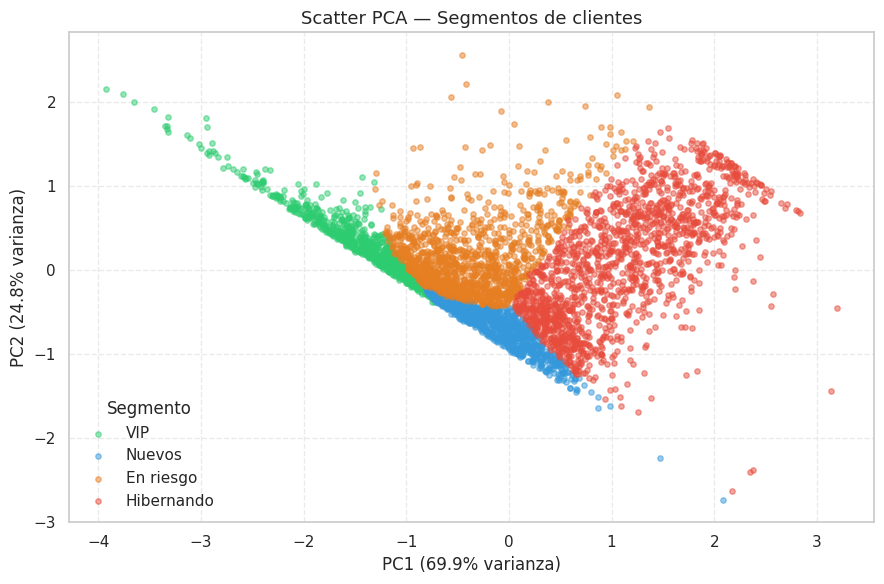

In [112]:
# ── Scatter PCA con nombres de segmento ──────────────────────

fig, ax = plt.subplots(figsize=(9, 6))

colors = {"VIP": "#2ecc71", "Nuevos": "#3498db", "En riesgo": "#e67e22", "Hibernando": "#e74c3c"}

for seg, color in colors.items():
    mask = rfm["segment"] == seg
    ax.scatter(
        rfm_pca_df.loc[mask, "PC1"],
        rfm_pca_df.loc[mask, "PC2"],
        c=color, label=seg, alpha=0.5, s=15
    )

ax.set_title("Scatter PCA — Segmentos de clientes", fontsize=13)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)")
ax.legend(title="Segmento", framealpha=0.8)
ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# **El PCA muestra que los 4 segmentos tienen separación geométrica clara, especialmente VIP. El solapamiento entre En riesgo e Hibernando es coherente con la naturaleza gradual del churn en retail.**

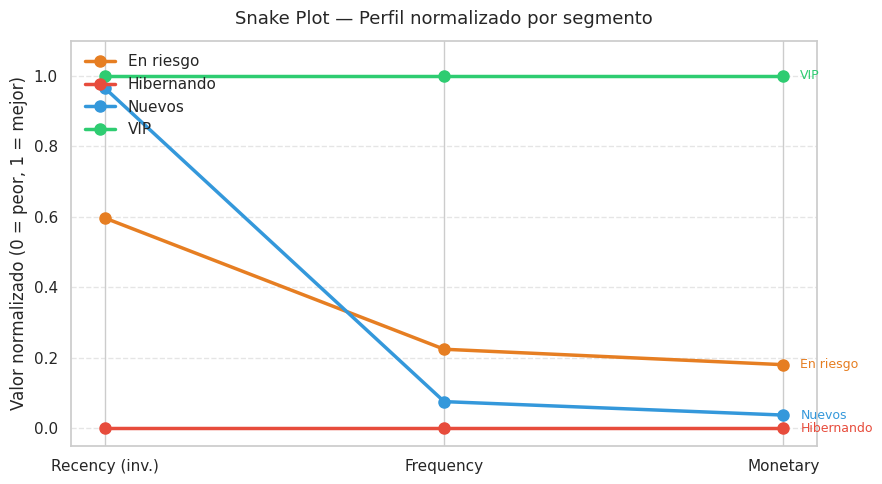

In [107]:
# ── Snake Plot ───────────────────────────────────────────
#
#  Normaliza R, F, M entre 0 y 1 para poder comparar
#  las tres variables en la misma escala.

from sklearn.preprocessing import MinMaxScaler

snake_df = rfm.groupby("segment")[["Recency", "Frequency", "Monetary"]].mean()

scaler_snake = MinMaxScaler()
snake_norm   = pd.DataFrame(
    scaler_snake.fit_transform(snake_df),
    index=snake_df.index,
    columns=snake_df.columns
)

# Invertir Recency: menor = mejor, así el gráfico es intuitivo
snake_norm["Recency"] = 1 - snake_norm["Recency"]
snake_norm.rename(columns={"Recency": "Recency (inv.)"}, inplace=True)

fig, ax = plt.subplots(figsize=(9, 5))

colors = {"VIP": "#2ecc71", "Nuevos": "#3498db", "En riesgo": "#e67e22", "Hibernando": "#e74c3c"}

for seg in snake_norm.index:
    color = colors.get(seg, "gray")
    ax.plot(snake_norm.columns, snake_norm.loc[seg], marker="o", linewidth=2.5,
            markersize=8, label=seg, color=color)
    # Etiqueta al final de la línea
    ax.annotate(seg, xy=(2, snake_norm.loc[seg].iloc[-1]),
                xytext=(2.05, snake_norm.loc[seg].iloc[-1]),
                va="center", fontsize=9, color=color)

ax.set_title("Snake Plot — Perfil normalizado por segmento", fontsize=13, pad=12)
ax.set_ylabel("Valor normalizado (0 = peor, 1 = mejor)")
ax.set_ylim(-0.05, 1.1)
ax.legend(loc="upper left", framealpha=0.8)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 🟢 VIP → línea plana en 1.0 desde Frequency en adelante. El mejor en todo.

## 🟠 En riesgo → empieza en 0.6 (compró hace relativamente poco) pero cae fuerte en Frequency y Monetary. Tenía potencial pero no fue constante.

## 🔵 Nuevos → empieza alto en Recency (compró recientemente) pero cae a casi 0 en Frequency y Monetary. Compró una vez y poco más.

## 🔴 Hibernando → línea plana en 0 en todo. El peor en las tres dimensiones.

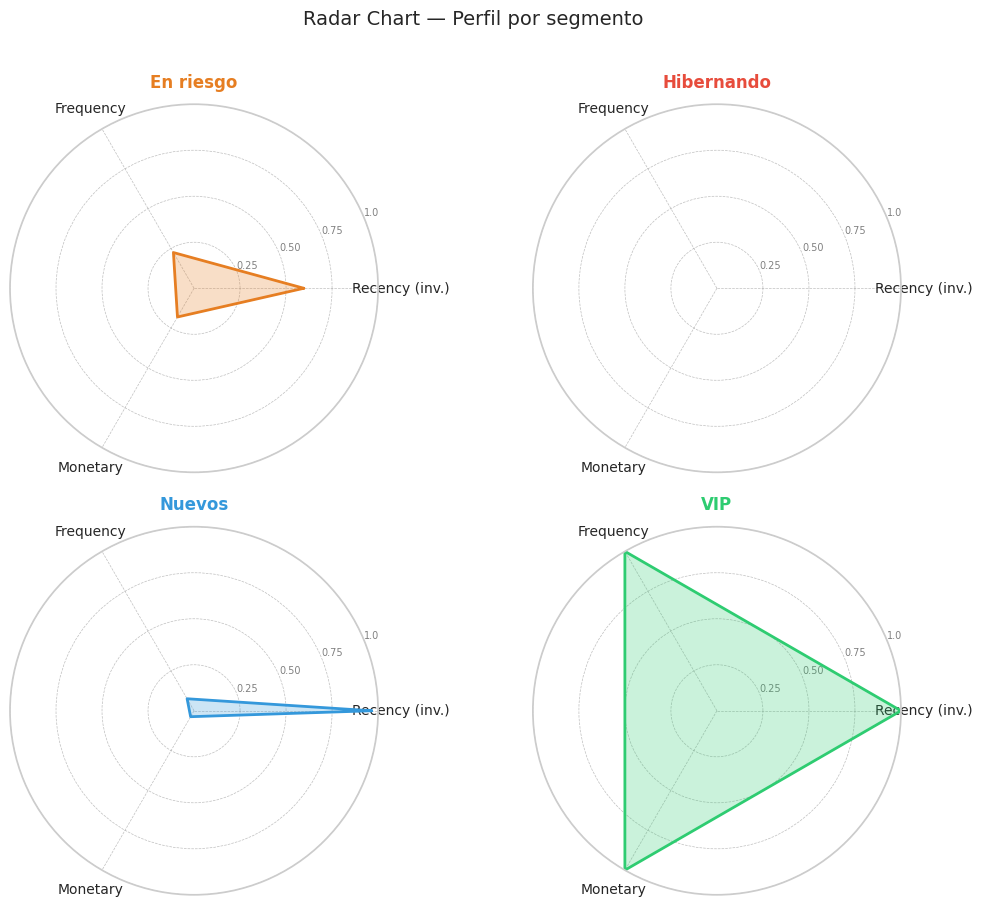

In [111]:
# ── Radar / Spider Chart ─────────────────────────────────

import matplotlib.patches as mpatches

segments  = snake_norm.index.tolist()
variables = snake_norm.columns.tolist()
N         = len(variables)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

fig, axes = plt.subplots(2, 2, figsize=(11, 9),
                         subplot_kw=dict(polar=True))
fig.suptitle("Radar Chart — Perfil por segmento", fontsize=14, y=1.01)

axes_flat = axes.flatten()

for i, seg in enumerate(segments):
    ax     = axes_flat[i]
    values = snake_norm.loc[seg].tolist()
    values += values[:1]
    color  = colors.get(seg, "gray")

    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(variables, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], fontsize=7, color="gray")
    ax.set_title(seg, size=12, color=color, pad=12, fontweight="bold")
    ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# **10- Conclusión**
- Recomendaciones

In [110]:
# ── 8.4 Recomendaciones de negocio ───────────────────────────

recomendaciones = {
    "VIP": {
        "descripcion": "Clientes de alto valor, compran frecuente y recientemente.",
        "accion":      "Programa de fidelización exclusivo, acceso anticipado a productos, descuentos por volumen.",
        "urgencia":    "🟢 Mantener — bajo riesgo de churn",
    },
    "Nuevos": {
        "descripcion": "Compraron recientemente pero con poca frecuencia y gasto bajo.",
        "accion":      "Campaña de onboarding, cupón de segunda compra, recomendaciones personalizadas.",
        "urgencia":    "🔵 Nutrir — alta oportunidad de conversión",
    },
    "En riesgo": {
        "descripcion": "Compraban bien pero llevan tiempo sin aparecer.",
        "accion":      "Email de reactivación con oferta, encuesta de satisfacción, descuento por volver.",
        "urgencia":    "🟠 Actuar pronto — ventana de rescate corta",
    },
    "Hibernando": {
        "descripcion": "Inactivos hace mucho, bajo valor histórico.",
        "accion":      "Campaña de win-back de bajo costo, evaluar si conviene invertir recursos.",
        "urgencia":    "🔴 Baja prioridad — costo de reactivación probablemente alto",
    },
}

print("=" * 65)
print("  RECOMENDACIONES DE NEGOCIO POR SEGMENTO")
print("=" * 65)

for seg, info in recomendaciones.items():
    if seg not in means.index:
        continue
    n   = rfm[rfm["segment"] == seg].shape[0]
    pct = n / len(rfm) * 100
    print(f"""
  [{seg}]  —  {n} clientes ({pct:.1f}% del total)
  Perfil:   {info['descripcion']}
  Acción:   {info['accion']}
  Urgencia: {info['urgencia']}""")

print("\n" + "=" * 65)

  RECOMENDACIONES DE NEGOCIO POR SEGMENTO

  [VIP]  —  763 clientes (17.7% del total)
  Perfil:   Clientes de alto valor, compran frecuente y recientemente.
  Acción:   Programa de fidelización exclusivo, acceso anticipado a productos, descuentos por volumen.
  Urgencia: 🟢 Mantener — bajo riesgo de churn

  [Nuevos]  —  822 clientes (19.0% del total)
  Perfil:   Compraron recientemente pero con poca frecuencia y gasto bajo.
  Acción:   Campaña de onboarding, cupón de segunda compra, recomendaciones personalizadas.
  Urgencia: 🔵 Nutrir — alta oportunidad de conversión

  [En riesgo]  —  1206 clientes (27.9% del total)
  Perfil:   Compraban bien pero llevan tiempo sin aparecer.
  Acción:   Email de reactivación con oferta, encuesta de satisfacción, descuento por volver.
  Urgencia: 🟠 Actuar pronto — ventana de rescate corta

  [Hibernando]  —  1531 clientes (35.4% del total)
  Perfil:   Inactivos hace mucho, bajo valor histórico.
  Acción:   Campaña de win-back de bajo costo, evaluar si 